In [4]:
import pandas as pd

df=pd.DataFrame({'Hours':[1,2,3,4,5,6,7,8,9,10,11,12,13,14],
            'Score':[64,66,76,73,74,81,83,82,80,88,84,91,93,89]})
df[0:6]

,Hours,Score
0,1,64
1,2,66
2,3,76
3,4,73
4,5,74
5,6,81


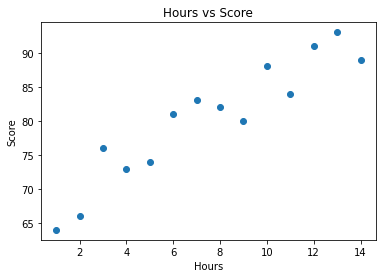

In [8]:
import matplotlib.pyplot as plt
plt.scatter(df.Hours,df.Score)
plt.title('Hours vs Score')
plt.xlabel('Hours')
plt.ylabel('Score')
plt.show()

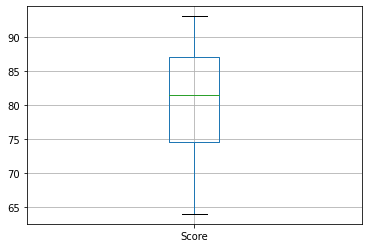

<AxesSubplot:>

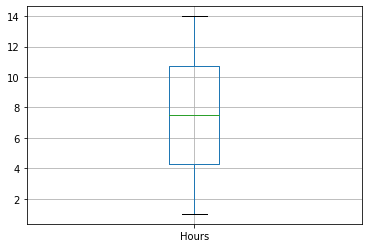

In [12]:
df.boxplot(column=['Score'])
plt.show()
df.boxplot(column=['Hours'])

In [14]:
import statsmodels.api as sm
y=df['Score']
x=df['Hours']
x=sm.add_constant(x)
model=sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     84.27
Date:                Fri, 27 May 2022   Prob (F-statistic):           8.95e-07
Time:                        13:58:36   Log-Likelihood:                -35.287
No. Observations:                  14   AIC:                             74.57
Df Residuals:                      12   BIC:                             75.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         65.4505      1.835     35.674      0.0

C:\Users\Rand Rothstein\anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


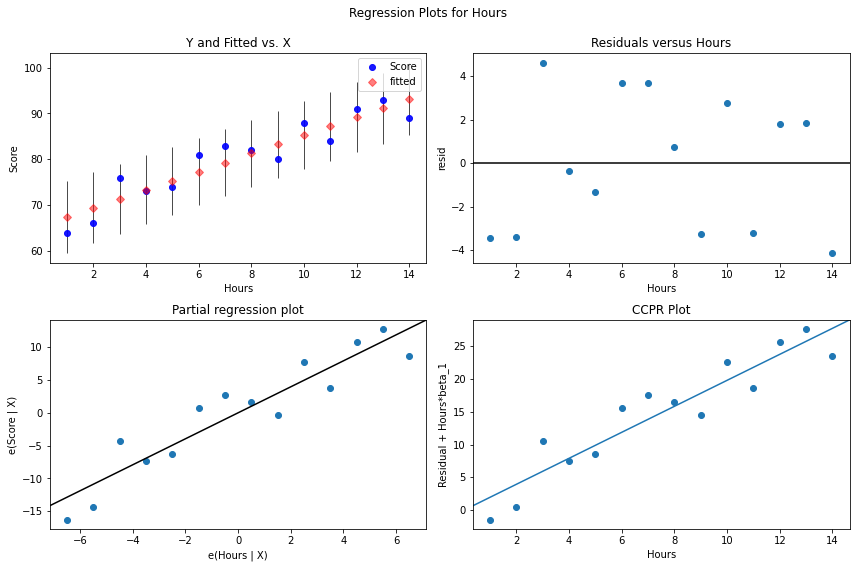

In [18]:
fig = plt.figure(figsize=(12,8))
fig = sm.graphics.plot_regress_exog(model,'Hours',fig=fig)

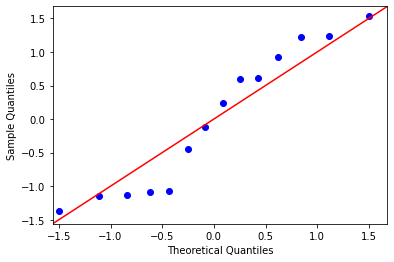

In [19]:
#Q-Q plot: This plot is useful for determining if the residuals 
#follow a normal distribution. If the data values in the plot fall 
#along a roughly straight line at a 45-degree angle, then the data 
#is normally distributed:
res=model.resid
fig=sm.qqplot(res,fit=True,line="45")
plt.show()

# Multilinear Regression

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Downloads\50_Startups.csv")
x=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values

In [40]:
print(x)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

In [41]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(missing_values=0.0,strategy='mean')
imputer.fit(x[:,:3])
x[:,:3]=imputer.transform(x[:,:3])

In [42]:
print(x[:,:3])

[[165349.2 136897.8 471784.1]
 [162597.7 151377.59 443898.53]
 [153441.51 101145.55 407934.54]
 [144372.41 118671.85 383199.62]
 [142107.34 91391.77 366168.42]
 [131876.9 99814.71 362861.36]
 [134615.46 147198.87 127716.82]
 [130298.13 145530.06 323876.68]
 [120542.52 148718.95 311613.29]
 [123334.88 108679.17 304981.62]
 [101913.08 110594.11 229160.95]
 [100671.96 91790.61 249744.55]
 [93863.75 127320.38 249839.44]
 [91992.39 135495.07 252664.93]
 [119943.24 156547.42 256512.92]
 [114523.61 122616.84 261776.23]
 [78013.11 121597.55 264346.06]
 [94657.16 145077.58 282574.31]
 [91749.16 114175.79 294919.57]
 [86419.7 153514.11 224494.78489361703]
 [76253.86 113867.3 298664.47]
 [78389.47 153773.43 299737.29]
 [73994.56 122782.75 303319.26]
 [67532.53 105751.03 304768.73]
 [77044.01 99281.34 140574.81]
 [64664.71 139553.16 137962.62]
 [75328.87 144135.98 134050.07]
 [72107.6 127864.55 353183.81]
 [66051.52 182645.56 118148.2]
 [65605.48 153032.06 107138.38]
 [61994.48 115641.28 91131.24]

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[3])],remainder='passthrough')
x=np.array(ct.fit_transform(x))

In [44]:
print(x)

[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [0.0 1.0 0.0 101913.08 110594.11 229160.95]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [0.0 1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 0.0 1.0 86419.7 153514.11 224494.78489361703]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 78389.47 153773.43 299737.29]
 [0.0 1.0 0.0 73994

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [46]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [47]:
y_pred=regressor.predict(x_test)

In [61]:
np.set_printoptions(precision=2) #number of decimals 
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[102388.94 103282.38]
 [121465.73 144259.4 ]
 [127340.58 146121.95]
 [ 71709.48  77798.83]
 [174211.08 191050.39]
 [121771.65 105008.31]
 [ 68393.54  81229.06]
 [ 95588.53  97483.56]
 [116596.35 110352.25]
 [162514.07 166187.94]]


# Model Selection - R Square

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Desktop\Machine Learning A-Z (Codes and Datasets)\Model Selection\Regression\Data.csv")
x=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [4]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [5]:
y_pred=regressor.predict(x_test)
np.set_printoptions(precision=2) #number of decimals 
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[431.43 431.23]
 [458.56 460.01]
 [462.75 461.14]
 ...
 [469.52 473.26]
 [442.42 438.  ]
 [461.88 463.28]]


In [6]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.9277905636321646